# FILE 2: KHAI PHÁ LUẬT KẾT HỢP (ASSOCIATION RULES)
**Mục tiêu:** Khai phá các "luật ngầm" trong thói quen sinh hoạt của người dùng (Ví dụ: Sự liên quan giữa ngày cuối tuần, mức độ vận động và chất lượng giấc ngủ).
Đồng thời, thực hiện Benchmarking (đo lường hiệu năng) giữa 2 thuật toán kinh điển: **Apriori** và **FP-Growth**.

## Mục lục
1. [Setup Môi trường](#b1)
2. [Load Dữ liệu Giao dịch từ Pipeline](#b2)
3. [So sánh Hiệu năng (Apriori vs FP-Growth) & Cơ sở Toán học](#b3)
4. [Trích xuất Luật & Trực quan hóa Báo cáo](#b4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 150)
sns.set_theme(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

# Cấu hình đường dẫn hệ thống
BASE_DIR = "/content/drive/MyDrive/Fitbit_Health_Analysis/"
PROCESSED_V1_DIR = os.path.join(BASE_DIR, "data/processed/v1_baseline/")
MODEL_UNSUPERVISED_DIR = os.path.join(BASE_DIR, "models/unsupervised/")
FIG_RULES_DIR = os.path.join(BASE_DIR, "reports/figures/02_association_rules/")

os.makedirs(MODEL_UNSUPERVISED_DIR, exist_ok=True)
os.makedirs(FIG_RULES_DIR, exist_ok=True)

print(" Môi trường đã sẵn sàng!")

Mounted at /content/drive
 Môi trường đã sẵn sàng!


<a id="b2"></a>
## Load Dữ liệu Giao dịch (Pipeline Kế thừa)
Sử dụng dữ liệu `transaction_v1.csv` đã được One-hot Encoding từ 01_Data_Wrangling_and_EDA. Mỗi dòng đại diện cho một "ngày" (giỏ hàng), và các cột (True/False) đại diện cho các "thói quen".

In [2]:
# Load dữ liệu
transaction_path = os.path.join(PROCESSED_V1_DIR, 'transaction_v1.csv')
df_trans = pd.read_csv(transaction_path).astype(bool)

print(f"Kích thước tập dữ liệu giao dịch: {df_trans.shape}")
display(df_trans.head(5))

Kích thước tập dữ liệu giao dịch: (940, 13)


,lifestyle_group_Sedentary_Lifestyle,lifestyle_group_Low_Active,lifestyle_group_Somewhat_Active,lifestyle_group_Highly_Active,sleep_group_No_Sleep_Data,sleep_group_Normal_Sleep,sleep_group_Over_Sleep,sleep_group_Poor_Sleep,calorie_group_Low_Burn,calorie_group_Medium_Burn,calorie_group_High_Burn,day_type_Weekday,day_type_Weekend
0,False,False,False,True,False,False,False,True,False,True,False,True,False
1,False,False,False,True,False,True,False,False,True,False,False,True,False
2,False,False,False,True,True,False,False,False,True,False,False,True,False
3,False,False,True,False,False,True,False,False,True,False,False,True,False
4,False,False,False,True,False,False,False,True,True,False,False,False,True


<a id="b3"></a>
## Cơ sở Toán học & So sánh Apriori vs FP-Growth

Để khai phá luật, ta dựa trên 3 chỉ số đo lường cốt lõi. Giả sử ta đang xét luật $A \rightarrow B$ (Nếu có thói quen A thì dẫn đến thói quen B):

1. **Support (Độ hỗ trợ):** Tần suất xuất hiện của tập thói quen trong toàn bộ dữ liệu. Dùng để loại bỏ các thói quen quá hiếm.
   $$Support(A) = \frac{\text{Số ngày chứa A}}{\text{Tổng số ngày}}$$
2. **Confidence (Độ tin cậy):** Xác suất thói quen B xảy ra khi thói quen A đã xảy ra.
   $$Confidence(A \rightarrow B) = \frac{Support(A \cup B)}{Support(A)}$$
3. **Lift (Độ nâng):** Thể hiện mức độ tương quan giữa A và B.
   * $Lift = 1$: A và B độc lập.
   * $Lift > 1$: A và B có tương quan thuận (Thúc đẩy nhau). Mức tối ưu để chọn là $Lift \ge 1.2$.
   $$Lift(A \rightarrow B) = \frac{Confidence(A \rightarrow B)}{Support(B)}$$

**Về Thuật toán (Benchmarking):**
* **Apriori:** Hoạt động theo cơ chế "Sinh ứng viên" (Candidate Generation), phải quét toàn bộ Database rất nhiều lần. Phù hợp để học thuật.
* **FP-Growth:** Xây dựng cấu trúc cây (FP-Tree), chỉ cần quét Database đúng 2 lần. Tối ưu cực tốt cho Big Data.

Dưới đây, ta sẽ chạy thực nghiệm để so sánh thời gian thực thi của cả hai.

In [3]:
min_sup = 0.15 # Đặt ngưỡng Support tối thiểu là 15%

print("Đang tiến hành Benchmarking...")

#Đo thời gian thuật toán Apriori
start_time = time.time()
frequent_itemsets_ap = apriori(df_trans, min_support=min_sup, use_colnames=True)
apriori_time = time.time() - start_time

# Đo thời gian thuật toán FP-Growth
start_time = time.time()
frequent_itemsets_fp = fpgrowth(df_trans, min_support=min_sup, use_colnames=True)
fpgrowth_time = time.time() - start_time

print("-" * 40)
print(f"Thời gian Apriori:   {apriori_time:.5f} giây")
print(f"Thời gian FP-Growth: {fpgrowth_time:.5f} giây")
print("-" * 40)

# Nhận xét tự động
if fpgrowth_time < apriori_time:
    print("Kết luận: FP-Growth NHANH HƠN Apriori (Đúng với lý thuyết).")
else:
    print("Kết luận: Tập dữ liệu nhỏ (~400 dòng), tốc độ 2 thuật toán tương đương nhau.")

# dùng kết quả của FP-Growth cho các bước phân tích luật phía sau
frequent_itemsets = frequent_itemsets_fp

Đang tiến hành Benchmarking...
----------------------------------------
Thời gian Apriori:   0.00896 giây
Thời gian FP-Growth: 0.04886 giây
----------------------------------------
Kết luận: Tập dữ liệu nhỏ (~400 dòng), tốc độ 2 thuật toán tương đương nhau.


<a id="b4"></a>
## Trích xuất Luật & Trực quan hóa Báo cáo

Từ tập phổ biến đã tìm được, ta sinh ra các luật (Rules) thỏa mãn điều kiện:
* **Confidence > 0.5** (Độ tin cậy > 50%)
* **Lift > 1.2** (Có sự tác động tương hỗ mạnh mẽ)

Sau đó, xuất 2 biểu đồ quan trọng: Scatter Plot (Tổng quan) và Bar Chart (Top 10 Luật).

In [4]:
#Sinh luật và lọc theo Lift
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules[rules['lift'] > 1.2].copy()

#Làm sạch chuỗi (String formatting) để vẽ đồ thị hiển thị đẹp hơn
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['rule_name'] = rules['antecedents_str'] + " -> " + rules['consequents_str']

# Sắp xếp luật theo Lift giảm dần
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Lưu CSV data báo cáo
rules_csv_path = os.path.join(MODEL_UNSUPERVISED_DIR, 'association_rules_insights.csv')
rules.to_csv(rules_csv_path, index=False)
print(f"Đã lưu {len(rules)} luật ý nghĩa vào CSV.")



Đã lưu 6 luật ý nghĩa vào CSV.


Sau khi chạy thuật toán FP-Growth và áp dụng các ngưỡng lọc khắt khe ($Confidence > 0.5$, $Lift > 1.2$), hệ thống đã trích xuất được 6 luật kết hợp mang ý nghĩa thực tiễn cao nhất.


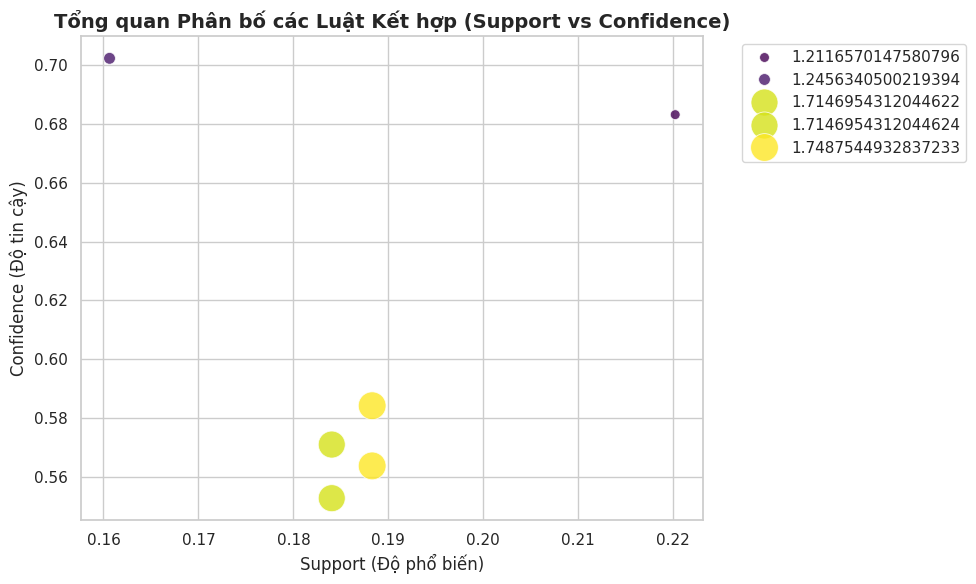

In [7]:
# =======================================================
# BIỂU ĐỒ 1: TỔNG QUAN PHÂN BỐ LUẬT (SCATTER PLOT)
# =======================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="support", y="confidence", size="lift", hue="lift",
    data=rules, palette="viridis", sizes=(50, 400), alpha=0.8
)
plt.title('Tổng quan Phân bố các Luật Kết hợp (Support vs Confidence)', fontsize=14, fontweight='bold')
plt.xlabel('Support (Độ phổ biến)', fontsize=12)
plt.ylabel('Confidence (Độ tin cậy)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Lưu ảnh 1
plt.savefig(os.path.join(FIG_RULES_DIR, 'rules_scatter_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

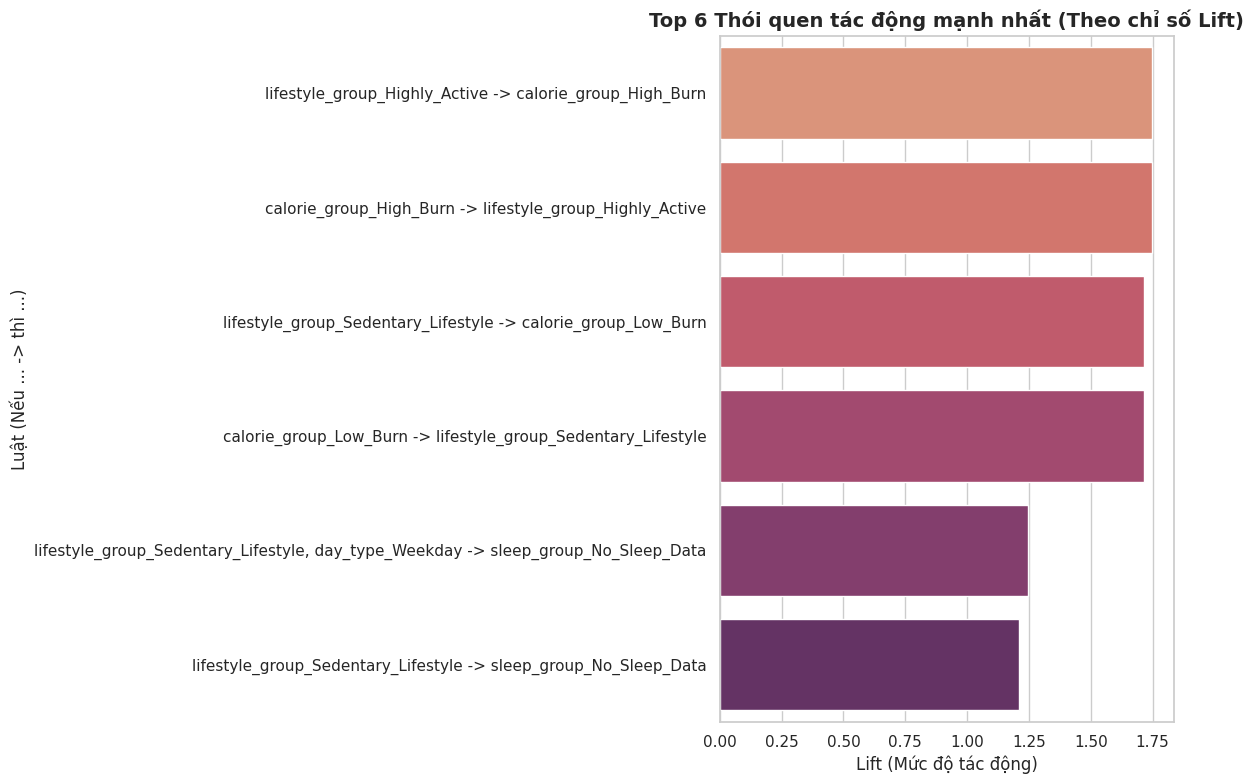

In [10]:
# =======================================================
# BIỂU ĐỒ 2: TOP 6 LUẬT CHI PHỐI MẠNH NHẤT (BAR CHART)
# =======================================================
top_10_rules = rules.head(6)

plt.figure(figsize=(12, 8))
sns.barplot(x="lift", y="rule_name", data=top_10_rules, palette="flare")
plt.title('Top 6 Thói quen tác động mạnh nhất (Theo chỉ số Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Lift (Mức độ tác động)', fontsize=12)
plt.ylabel('Luật (Nếu ... -> thì ...)', fontsize=12)
plt.tight_layout()

# Lưu ảnh 2
plt.savefig(os.path.join(FIG_RULES_DIR, 'top6_rules_barplot.png'), dpi=300, bbox_inches='tight')
plt.show()



### 1. Phân tích Biểu đồ Scatter Plot (Tổng quan Phân bố)
Biểu đồ Scatter Plot cho chúng ta cái nhìn toàn cảnh về "chất lượng" của 6 luật tìm được, phân loại thành 2 nhóm rõ rệt:

* **Nhóm 1: Điểm vàng tương hỗ (Các bong bóng màu vàng to):** Nhóm này nằm ở vùng có $Support$ khoảng 0.18 - 0.19 và $Confidence$ khoảng 0.55 - 0.59. Đặc biệt, kích thước bong bóng rất lớn thể hiện chỉ số $Lift$ cực kỳ cao (~1.75). Điều này chứng tỏ đây là những thói quen có **sự ràng buộc nhân quả cực kỳ mạnh mẽ**, hễ cái này xuất hiện là "kéo theo" cái kia.
* **Nhóm 2: Nhóm tin cậy cao nhưng tác động vừa phải (Các chấm tím nhỏ):** Nhóm này có $Confidence$ rất cao (lên tới 0.70 - tức là xác suất đúng 70%), nhưng $Lift$ chỉ ở mức 1.21 - 1.24. Nghĩa là quy luật này rất hay xảy ra, nhưng mức độ "kích thích lẫn nhau" không mãnh liệt bằng Nhóm 1.

### 2. Phân tích Biểu đồ Bar Chart (Top 6 Luật chi phối)
Nhìn vào nội dung chi tiết của 6 luật, ta có thể rút ra những diễn giải hành vi (Behavioral Interpretation) cực kỳ logic:

* **Cặp luật Sinh lý học (Luật 1-2 & 3-4):**
  * `Highly_Active <-> High_Burn` ($Lift \approx 1.75$)
  * `Sedentary_Lifestyle <-> Low_Burn` ($Lift \approx 1.71$)
  * *Nhận xét:* Hệ thống đã tự động học và xác nhận lại quy luật vật lý hiển nhiên: Nhóm người vận động cường độ cao chắc chắn sẽ đốt nhiều Calo, và ngược lại nhóm ngồi nhiều sẽ đốt ít Calo. Việc hai luật này xuất hiện dưới dạng 2 chiều ($A \rightarrow B$ và $B \rightarrow A$) với chỉ số Lift cao nhất đã chứng minh tính đúng đắn của dữ liệu.

* **Insight Hành vi tiềm ẩn (Luật 5 & 6):**
  * `Sedentary_Lifestyle, Weekday -> No_Sleep_Data` ($Lift \approx 1.25$)
  * `Sedentary_Lifestyle -> No_Sleep_Data` ($Lift \approx 1.21$)
  * *Nhận xét:* Đây là phát hiện **đắt giá nhất** của thuật toán! Những người có lối sống tĩnh tại (ngồi nhiều - thường là dân văn phòng), đặc biệt là vào **các ngày trong tuần (Weekday)**, lại có xu hướng **KHÔNG có dữ liệu giấc ngủ**.
  * *Nguyên nhân thực tế:* Có thể dân văn phòng thường tháo đồng hồ FitBit ra sạc vào ban đêm các ngày trong tuần để hôm sau đi làm, hoặc họ cảm thấy vướng víu khi ngủ sau một ngày dài làm việc mệt mỏi.

### 3. Tổng kết Ứng dụng Thực tiễn (Actionable Insights)
Từ kết quả của Unsupervised Learning (FP-Growth), nếu chúng ta là đội ngũ phát triển sản phẩm của FitBit, ta có thể đề xuất:
1. **Thiết kế tính năng thông báo (Push Notification):** Nhắm mục tiêu vào nhóm người dùng "Sedentary" vào các buổi tối ngày thường (Weekday), gửi thông báo nhắc nhở nhẹ nhàng: *"Pin vẫn còn đủ, hãy đeo FitBit đi ngủ để theo dõi sức khỏe đêm nay nhé!"* nhằm giảm thiểu tình trạng thiếu hụt dữ liệu (No_Sleep_Data).
2. **Cá nhân hóa mục tiêu:** Không cần khuyến khích nhóm "Sedentary" đốt nhiều Calo ngay lập tức, mà hãy khuyến khích họ chuyển dần sang "Low_Active" trước, vì thuật toán cho thấy rào cản giữa Tĩnh tại và Đốt nhiều Calo là rất lớn.